Computing a global dendrogram by merging local dendrograms
==========================================================

This notebook explains one algorithm for distributing the dendrogram computation.
The algorithm has the following steps
- distribute the data among processes
- compute local dendrograms on each process in parallel
- gather the local dendrograms on one task
- Further break apart local structures on any extreme points
- recompute the dendrogram, but on the chunks from local structures

This will not scale perfectly because the merging of local dendrograms is a serial bottleneck.
In the worst case, every pixel is its own structure and the full dendrogram is computed from scratch on a single task again, which should take at most twice as long as the serial case.
The algorithm works better, the fewer structures are identified.
This implies few chunks to merge in the serial dendrogram computation.

For example, with $N$ data points, the serial dendrogram needs $N$ iterations.
Splitting the data among $P$ processes, we need $N/P$ iterations on each local task.
Then, we get $M\leq N$ chunks of data that we need to recompute the dendrogram on, requiring another $M$ iterations.
So, the speedup is $S\approx \frac{N}{N/P + M}\geq 1/(P + 1)$.
$M$ depends on $P$ and on how many structures there are in the data.
It remains to be seen how well this performs on real world data.

1D example
----------

Let's start by doing some imports and defining the data as well as the astrodendro dendrogram that we want to compute.

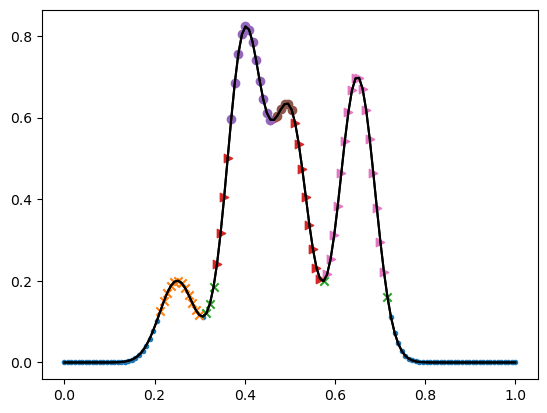

In [1]:
# ruff: noqa: E402
import numpy as np
import matplotlib.pyplot as plt
from dendro.utils import get_1d_data, plot_astrodendro_leaves, compare_dendrograms
from astrodendro.dendrogram import Dendrogram

x, data = get_1d_data(128)
x = x.numpy()
data = data.numpy()

fig, ax = plt.subplots()
ax.plot(x, data, color="black")

reference_dendrogram = Dendrogram.compute(data)
plot_astrodendro_leaves(ax, x, data, reference_dendrogram.trunk)

Next, we are going to split up the data into chunks and compute the local the dendrograms independently.
This part is where the speedup comes from: Because the time to compute a astrodendro dendrogram scales linearly with the number of data points, on $N$ tasks, we need only $1/N$ of the time compared to serial computation.
Of course, we still need to merge the local dendrograms after, reducing the speedup we actually get.

Text(0.5, 1.0, 'All tasks')

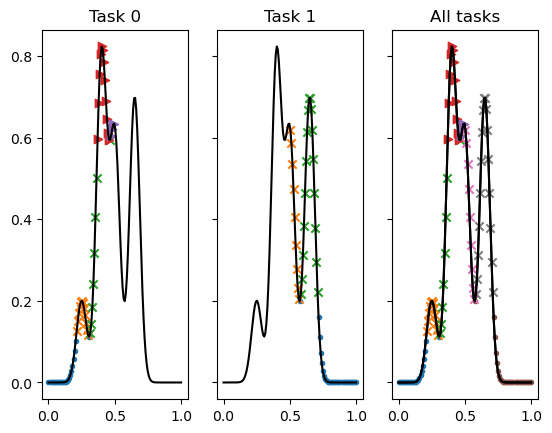

In [2]:
from dendro.distributed_dendrogram_v3 import DistributedDendrogramV3

ntasks = 2
local_dendrograms = DistributedDendrogramV3.compute_local_dendrogram_pseudo_parallel(
    data, ntasks=ntasks
)

fig, axs = plt.subplots(1, ntasks + 1, sharey=True)
for i, d in enumerate(local_dendrograms):
    axs[i].set_title(f"Task {i}")
    plot_astrodendro_leaves(axs[i], x, data, d.trunk)
    plot_astrodendro_leaves(axs[-1], x, data, d.trunk)
axs[-1].set_title("All tasks")

Now, we have to merge these local dendrograms!
In order to properly illustrate everything, we will write down the entire algorithm here and do a lot of plotting of intermediate steps.

First, we instantiate the dendrogram.

In [3]:
d = DistributedDendrogramV3()
d.data = data

Before we can get to merging, we collect all structures of any local dendrogram.
We need to add offsets in order to make sure we can tell the structures apart later.

In [4]:
all_structures = []
for ld in local_dendrograms:
    structures = [structure for structure in ld.all_structures]
    offset = len(all_structures)
    for structure in structures:
        structure.idx += offset

    all_structures += structures
structures = all_structures

Now, on to recomputing the dendrograms on chunks of data.
We prepare an index map, just like serial astrodendro for keeping track of where the structures are.
If you don't know what the index map is about, don't worry about it.
All you need to know is that it allows to efficiently compute which structures are adjacent.

In [5]:
d.index_map = -np.ones(np.add(d.data.shape, 1), dtype=np.int32)

Now, we sort the structures by the maximal value and loop through from top to bottom.
In the loop we check how many structures are adjacent in the merged dendrogram.
If we have no adjacent structures, we create a new leaf, if we have one, we merge into the leaf, and if we have more, we create a branch that is the parent to all adjacent structures.

The important part is that we may need to break apart structures.
We decide this for every structure that we merge individually.
When we merge into a structure, we merge only the parts until the larger minimum of the two structures.
The remainder is split off and merged later.
It doesn't matter which structure has smaller values, the one to be merged or the one to merge into.
We do this because a part of either may be part of the parent of the merged structure.

When we create a parent, we also split any children or the structure to be merged if children have smaller values than the structure to be merged.

Below, you will find plots of the structures we have yet to merge, the structures we have already merged, and the changes within a single merge.
Pay attention to structures that are split at local extrema.

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_88785/1655303550.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[3].legend(frameon=False)


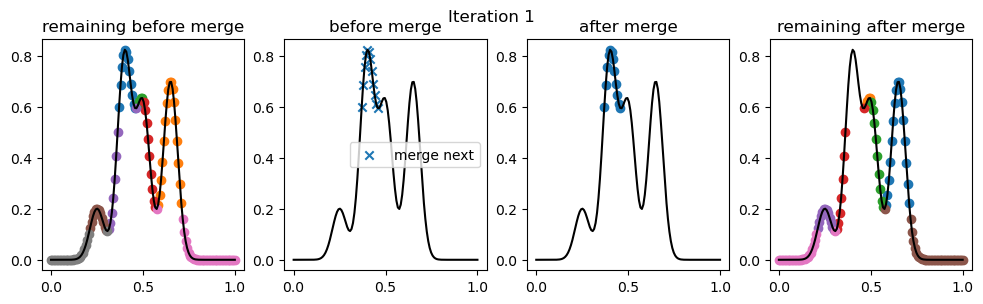

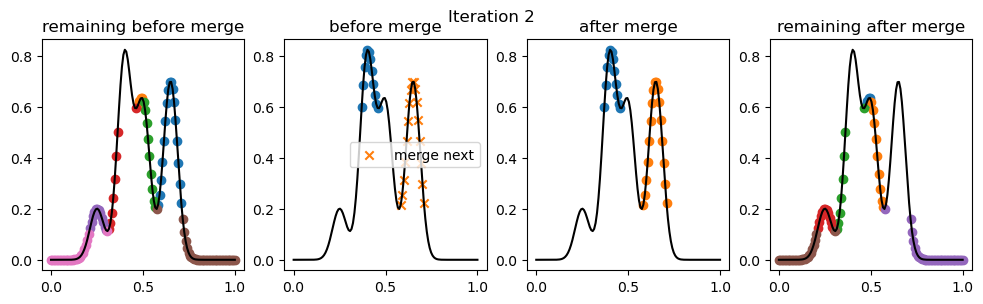

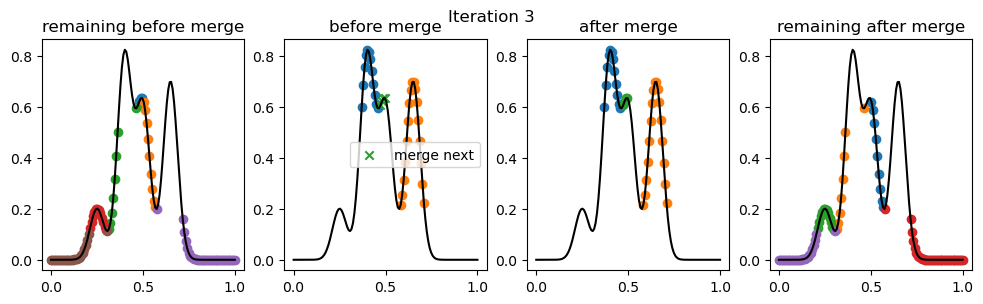

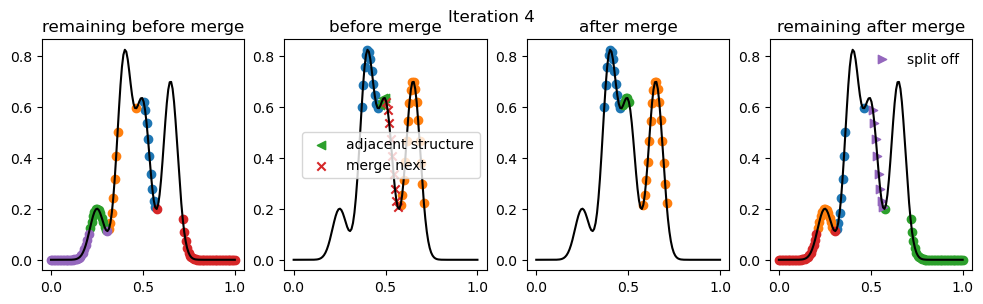

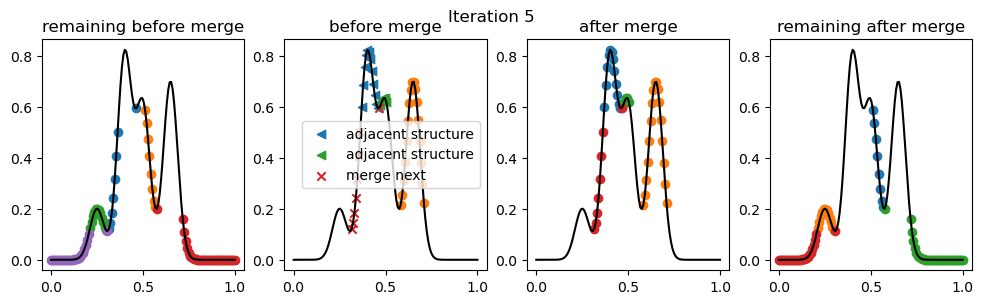

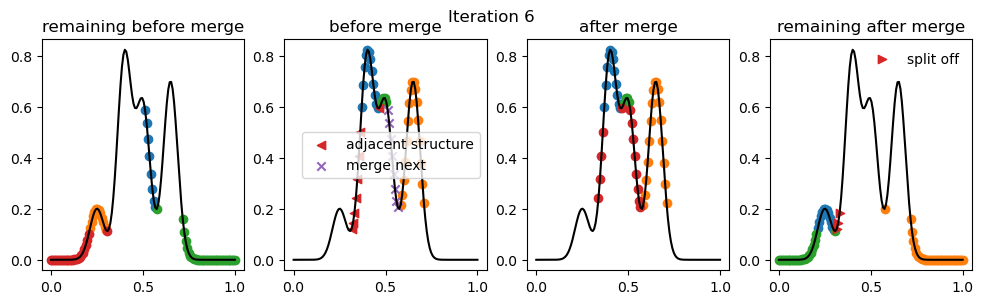

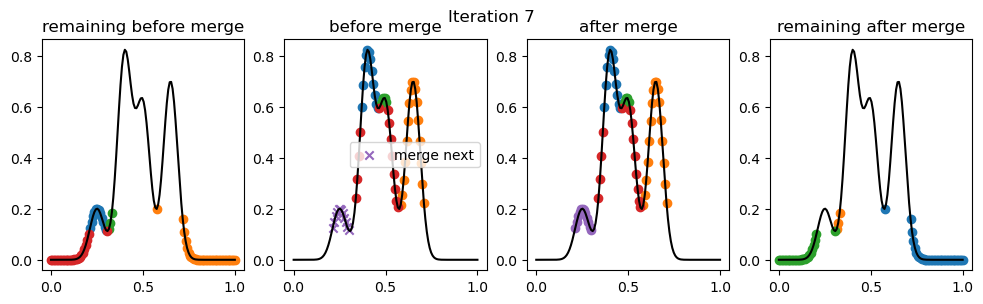

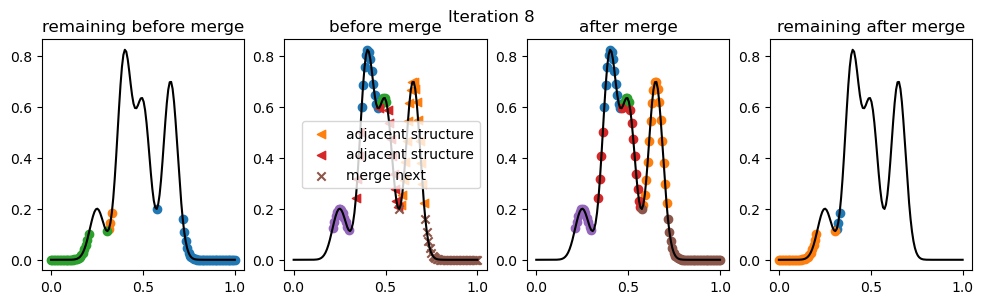

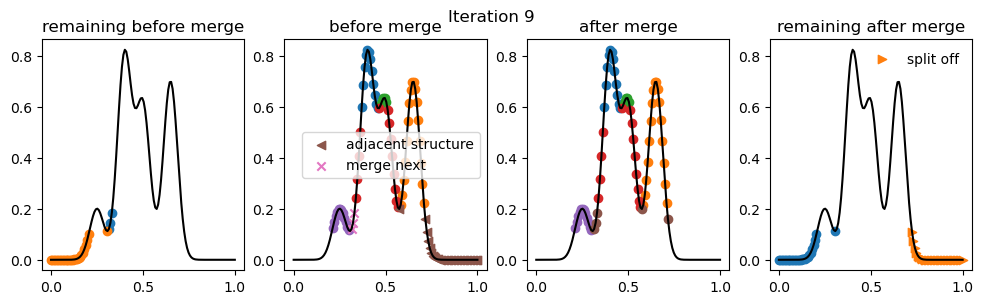

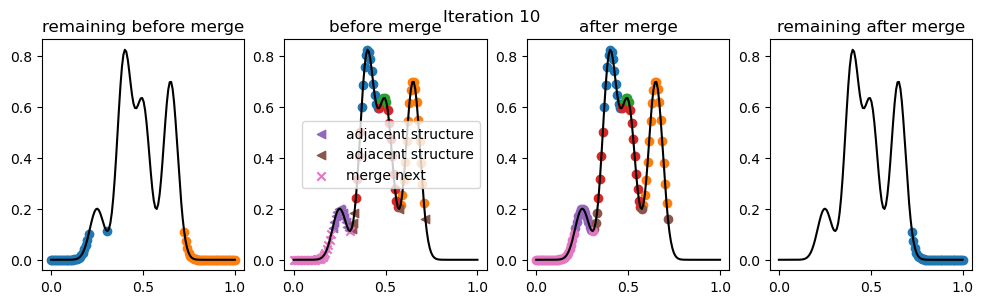

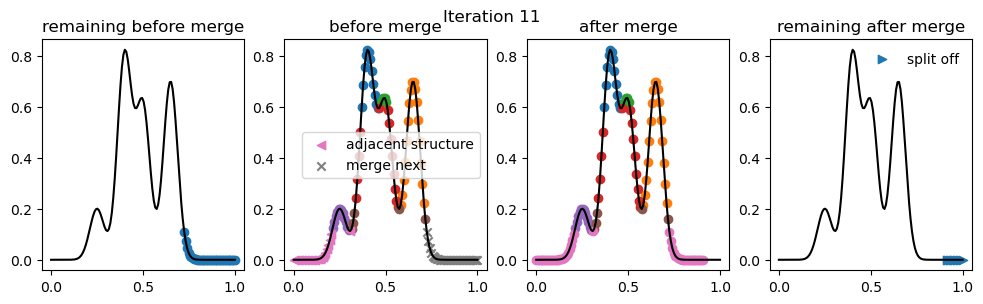

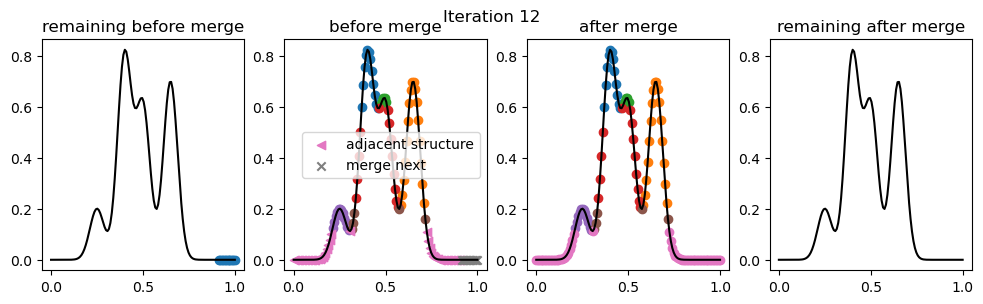

In [6]:
structures = d.sort_structures(structures)
merged_structures = []

iteration = 0
while len(structures) > 0:
    iteration += 1
    fig, axs = plt.subplots(1, 4, figsize=(12, 3))
    for ax in axs:
        ax.cla()
        ax.plot(x, data, color="black")

    axs[0].set_title("remaining before merge")
    axs[1].set_title("before merge")
    axs[2].set_title("after merge")
    axs[3].set_title("remaining after merge")
    fig.suptitle(f"Iteration {iteration}")

    for structure in structures:
        axs[0].scatter(
            x[structure._indices.flatten()], data[structure._indices.flatten()]
        )

    to_merge = structures.pop(0)

    old_structures = []
    for structure in structures:
        old_structures.append(structure)
        axs[3].scatter(
            x[structure._indices.flatten()], data[structure._indices.flatten()]
        )

    # find adjacent structures
    adjacent_structures = d.get_adjacent_structures(
        to_merge, merged_structures, d.index_map
    )
    for structure in merged_structures:
        if structure in adjacent_structures:
            axs[1].scatter(
                x[structure._indices.flatten()],
                data[structure._indices.flatten()],
                marker="<",
                label="adjacent structure",
            )
        else:
            axs[1].scatter(
                x[structure._indices.flatten()], data[structure._indices.flatten()]
            )
    axs[1].scatter(
        x[to_merge._indices.flatten()],
        data[to_merge._indices.flatten()],
        label="merge next",
        marker="x",
    )

    # merge the structure into the dendrogram
    merged_structures, structures = d.merge_individual_structure(
        to_merge, merged_structures, adjacent_structures, structures
    )

    for structure in merged_structures:
        axs[2].scatter(
            x[structure._indices.flatten()], data[structure._indices.flatten()]
        )

    for structure in structures:
        if structure not in old_structures:
            axs[3].scatter(
                x[structure._indices.flatten()],
                data[structure._indices.flatten()],
                marker=">",
                label="split off",
            )

    axs[1].legend(frameon=True)
    axs[3].legend(frameon=False)

d._trunk = [structure for structure in merged_structures if structure.parent is None]

The above logic is conveniently implemented in a single function and can be use like so:

INFO:Dendrogram:Start merging 8 structures from local dendrograms into one global one.


INFO:Dendrogram:Starting iteration 1 of merging dendrograms. Merged dendrogram contains 0 structures and have 8 left to merge.


INFO:Dendrogram:Merging structure with 12 values between 0.60 and 0.82 with 0 adjacent structures.


INFO:Dendrogram:Created new leaf with 12 values between 0.60 and 0.82.


INFO:Dendrogram:Starting iteration 2 of merging dendrograms. Merged dendrogram contains 1 structures and have 7 left to merge.


...

INFO:Dendrogram:Inserted structure with 12 values between 0.00 and 0.00 into list of 1 remaining structures.


INFO:Dendrogram:Merged 24 values between 0.00 and 0.11 into existing structure, which now has 52 values between 0.00 and 0.11


INFO:Dendrogram:Starting iteration 12 of merging dendrograms. Merged dendrogram contains 7 structures and have 1 left to merge.


INFO:Dendrogram:Merging structure with 12 values between 0.00 and 0.00 with 1 adjacent structures.


INFO:Dendrogram:Merged 12 values between 0.00 and 0.00 into existing structure, which now has 64 values between 0.00 and 0.00


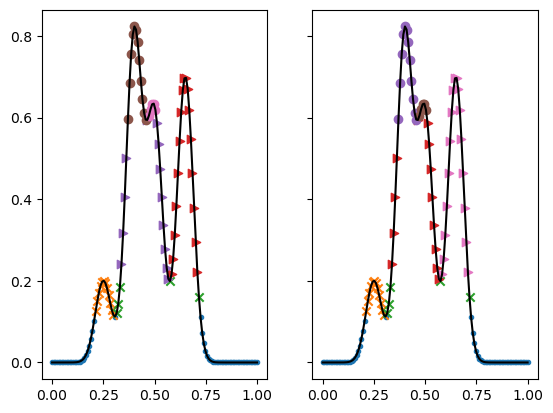

In [7]:
import logging

logging.basicConfig(level=logging.INFO)
merged_dendrogram = DistributedDendrogramV3.compute_pseudo_parallel(data, ntasks)

fig, axs = plt.subplots(1, 2, sharey=True)
plot_astrodendro_leaves(axs[0], x, data, merged_dendrogram.trunk)
plot_astrodendro_leaves(axs[1], x, data, reference_dendrogram.trunk)

We can also rigorously check that the two are identical:

In [8]:
compare_dendrograms(reference_dendrogram, merged_dendrogram)